## Calculating Bore offsets for the AuxTel filters

Will use source finding to calculate offsets\
Craig Lage - 17-Mar-21

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import astropy.io.fits as pf
from astropy.time import Time, TimeDelta
import pickle as pkl
from lsst.daf.persistence import Butler
from lsst.pipe.tasks.characterizeImage import CharacterizeImageTask, CharacterizeImageConfig
from lsst.rapid.analysis.summarizeImage import SummarizeImage

In [2]:
# Get the raw quickLook data
REPO_DIR = '/project/shared/auxTel/rerun/quickLook'
butler = Butler(REPO_DIR)
dayObs = '2021-03-11'

In [3]:
charConfig = CharacterizeImageConfig()
charConfig.doMeasurePsf = True
charConfig.doApCorr = False
charConfig.doDeblend = False
charConfig.repair.doCosmicRay = True
charConfig.repair.doInterpolate = True   
charConfig.detection.minPixels = 500
charTask = CharacterizeImageTask(config=charConfig)

In [ ]:
allResults={}
for expId in range(2021031100184, 2021031100194+1):
    result = {}
    exp = butler.get('quickLookExp', detector=0, expId=expId)
    result['exp'] = exp
    mData = exp.getMetadata()
    timeObs = mData['DATE-BEG']
    result['Time'] = timeObs
    print(f"Exposure {expId} was at {timeObs}")
    if expId in [2021031100184, 2021031100194]: # Non-dispersed images
        charResult = charTask.run(exp)
        sourceCatalog = charResult.sourceCat
        result['sourceCatalog'] = sourceCatalog
        result['qfmResult'] = None
        print(f"Found {len(sourceCatalog)} sources")
        maxFlux = np.nanmax(sourceCatalog['base_SdssShape_instFlux'])
        selectBrightestSource = sourceCatalog['base_SdssShape_instFlux'] > maxFlux * 0.99
        brightestSource = sourceCatalog.subset(selectBrightestSource)
        brightestCentroid = (brightestSource['base_SdssCentroid_x'][0], \
                             brightestSource['base_SdssCentroid_y'][0])
    else:
        summarise = SummarizeImage(exp)
        summarise.run()
        result['sourceCatalog'] = None
        result['qfmResult'] = summarise.qfmResult
        brightestCentroid = summarise.qfmResult.brightestObjCentroid
    result['brightestCentroid'] = brightestCentroid
    print(f"Exposure {expId} brightest star is at {brightestCentroid}")
    allResults[str(expId)] = result

In [ ]:
filename = '/home/craiglagegit/DATA/boresight_catalogs.pkl'
outfile = open(filename,'wb')
pkl.dump(allResults,outfile)
outfile.close()

In [4]:
filename = '/home/craiglagegit/DATA/boresight_catalogs.pkl'
infile = open(filename, "rb")
allResults = pkl.load(infile)
infile.close()

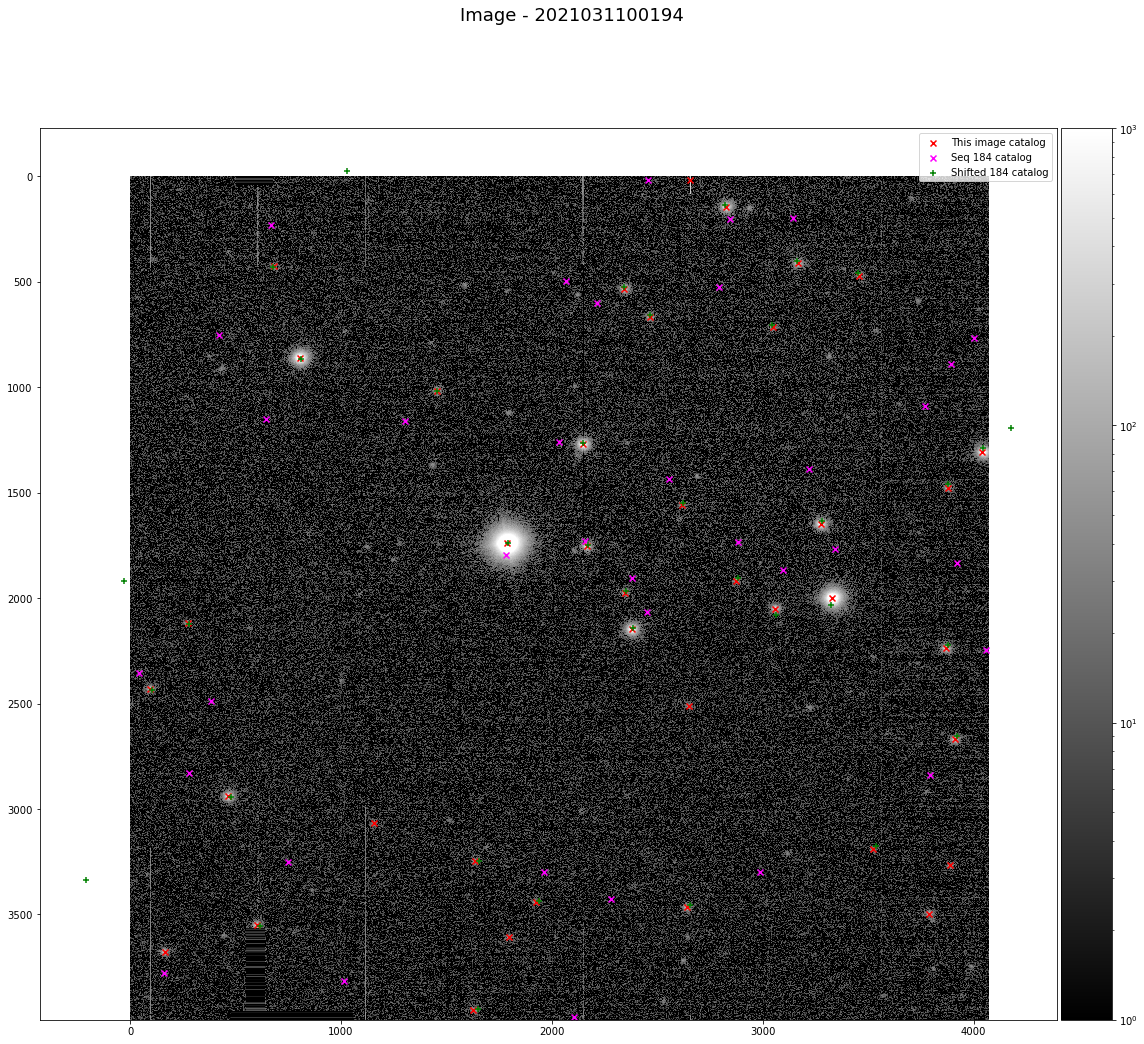

In [119]:
%matplotlib inline
expId = 2021031100194
exp = allResults[str(expId)]['exp']
sourceCatalog = allResults[str(expId)]['sourceCatalog']
cat_184 = allResults[str('2021031100184')]['sourceCatalog']
# Look at the data with matplotlib
def colorbar(mappable):
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    last_axes = plt.gca()
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(mappable, cax=cax)
    plt.sca(last_axes)
    return cbar

plt.figure(figsize=(16,16))
plt.suptitle(f"Image - {expId}",fontsize=18)
#plt.subplot(1,1,1)
arr = exp.image.array
arr = np.clip(arr, 1, 100000) # This image has some negative values, and this removes them
#img = plt.imshow(arr, norm=LogNorm(vmin=1, vmax=1000),  interpolation='Nearest', cmap='gray')
#colorbar(img)
plt.subplot(1,1,1)
img = plt.imshow(arr, norm=LogNorm(vmin=1, vmax=1000),  interpolation='Nearest', cmap='gray')
plt.scatter(sourceCatalog['base_SdssCentroid_x'],sourceCatalog['base_SdssCentroid_y']\
            ,color='red', marker='x', label='This image catalog')
plt.scatter(cat_184['base_SdssCentroid_x'],cat_184['base_SdssCentroid_y']\
            ,color='magenta', marker='x', label='Seq 184 catalog')
time = Time(allResults[str(expId)]['Time'])
newXY = rotate_and_translate_catalog(time)
plt.scatter(newXY[:,0],newXY[:,1]\
           ,color='green', marker='+', label='Shifted 184 catalog')
colorbar(img)
plt.legend()
plt.tight_layout(h_pad=1)
plt.savefig(f"/home/craiglagegit/DATA/Boresight_{expId}_18Mar21.pdf")

In [106]:
def rotate_and_translate_catalog(time, expId=2021031100184):
    center = np.array([2036.0, 2000.0])
    t0 = Time(allResults[str(expId)]['Time'])
    deltaT = TimeDelta(time - t0, format='sec').value
    #print(f"deltaT = {deltaT}")
    angle = -0.21 / 1101.0 * deltaT
    shift = np.array([-40.0, -10.0]) / 1101.0 * deltaT
    rot_matrix = np.array([[np.cos(angle), np.sin(angle)],[-np.sin(angle), np.cos(angle)]])
    cat = allResults[str(expId)]['sourceCatalog']
    numObjects = len(cat)
    newXY = np.zeros([len(cat),2])
    for i in range(numObjects):
        xy = np.array((cat['base_SdssCentroid_x'][i], cat['base_SdssCentroid_y'][i]))
        xy -= center # distance from center
        new_xy = np.dot(rot_matrix, xy) + center + shift
        newXY[i,0] = new_xy[0]; newXY[i,1] = new_xy[1]
    return newXY
    

In [124]:
# Now finally, we can calculate the offsets
plate_scale = 0.1 # (arcseconds/pixel)
ronchi_90 = np.zeros([2])
ronchi_170 = np.zeros([2])
holo = np.zeros([2])
for expId in range(2021031100185, 2021031100193+1):
    brightest_index = 19
    time = Time(allResults[str(expId)]['Time'])
    newXY = rotate_and_translate_catalog(time)
    bright_183 = newXY[brightest_index]
    bright_this = np.array(allResults[str(expId)]['brightestCentroid'])
    boresight_shift = bright_this - bright_183        
    print(f"For {expId}, boresight shift = {boresight_shift}.")
    if expId in [2021031100185, 2021031100186, 2021031100187]:
        ronchi_90 += boresight_shift
    if expId in [2021031100188, 2021031100189, 2021031100190]:
        ronchi_170 += boresight_shift
    if expId in [2021031100191, 2021031100192, 2021031100193]:
        holo += boresight_shift 
ronchi_90 = ronchi_90 / 3.0 * plate_scale
ronchi_170 = ronchi_170 / 3.0 * plate_scale
holo = holo / 3.0 * plate_scale
print(f" Ronchi_90 boresight shift = ({ronchi_90[0]:.1f}, {ronchi_90[1]:.1f}) arcseconds")
print(f" Ronchi_170 boresight shift = ({ronchi_170[0]:.1f}, {ronchi_170[1]:.1f}) arcseconds")
print(f" Holo boresight shift = ({holo[0]:.1f}, {holo[1]:.1f}) arcseconds")

For 2021031100185, boresight shift = [-171.10463164   11.74201488].
For 2021031100186, boresight shift = [-171.55229831   15.19546485].
For 2021031100187, boresight shift = [-169.22834769   12.26012271].
For 2021031100188, boresight shift = [-166.15971762   13.57599381].
For 2021031100189, boresight shift = [-165.32281596   15.18275662].
For 2021031100190, boresight shift = [-162.29419523   11.00655757].
For 2021031100191, boresight shift = [-7.20586736  6.53965217].
For 2021031100192, boresight shift = [-8.57810674 14.20578315].
For 2021031100193, boresight shift = [-3.30197378 12.51936938].
 Ronchi_90 boresight shift = (-17.1, 1.3) arcseconds
 Ronchi_170 boresight shift = (-16.5, 1.3) arcseconds
 Holo boresight shift = (-0.6, 1.1) arcseconds


In [ ]:
# Now looking at the focus offsets

# Best focus with no grating - Seq # 119 - FocusZ = -0.2000, HexZ = 0.1599
# Focus on Ronchi90 with supplied offset - Seq # 156 - FocusZ = -0.1143, HexZ = 0.1643
# Focus sequence with no grating - Seq # 184 - FocusZ = -0.1143, HexZ = 0.2156 
# Best focus with Ronchi170 - Seq # 276 - FocusZ = +0.0164, HexZ = 0.2951 Offset(from FocusZ) = +0.2164
# Best focus with Holo - Seq # 293 - FocusZ = -0.0936, HexZ = 0.2366 Offset(from FocusZ) = +0.1064